<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/Suman_Gamma_arylation_Full_Coorelation_Matrix_v9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



RAW / FULL CORRELATION ANALYSIS
Number of ligands: 19

Yield successfully assigned.
Ligand  Yield
    L7      0
    L8      0
    L9      0
   L10      0
   L11      0
   L12      0
   L13      0
   L14      0
   L15      0
   L16     12
   L17     53
   L18     46
   L19     67
   L20     40
   L21     31
   L22      0
   L23      0
   L24      0
   L25      0


IMPORTANT DESCRIPTOR STATUS
✓ Pd_Oriented_Sterimol_B1_A
    N     = 19
    Min   = 1.689513
    Max   = 2.654875
    Range = 0.965362
✓ Pd_Oriented_Sterimol_B5_A
    N     = 19
    Min   = 5.326594
    Max   = 8.664630
    Range = 3.338036
✓ Pd_Oriented_Sterimol_L_A
    N     = 19
    Min   = 7.190173
    Max   = 8.057538
    Range = 0.867365
✓ Ligand_%Vbur_3.0A
    N     = 19
    Min   = 32.923309
    Max   = 46.174762
    Range = 13.251453
✓ Ligand_%Vbur_3.5A
    N     = 19
    Min   = 30.457394
    Max   = 45.060334
    Range = 14.602940
✓ Ligand_%Vbur_4.0A
    N     = 19
    Min   = 27.269024
    Max   = 44.014183
    Ra

,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Pearson_r,Abs_Spearman_rho,Mean_Abs_Correlation
0,Pd_Donor1_Distance_A,19,-0.728209,0.000408,-0.757001,0.000175,0.728209,0.757001,0.742605
1,Palladacycle_Ring_Size,19,0.575878,0.009871,0.629801,0.003854,0.575878,0.629801,0.602839
2,Donor1_Donor2_Distance_A,19,0.557718,0.013095,0.589015,0.007966,0.557718,0.589015,0.573367
3,Bite_Angle_deg,19,0.573648,0.010228,0.525223,0.020932,0.573648,0.525223,0.549436
4,Pd_Oriented_Sterimol_B5_A,19,0.409090,0.082005,0.486948,0.034478,0.409090,0.486948,0.448019
5,Ligand_%Vbur_3.0A,19,0.383662,0.104895,0.503959,0.027804,0.383662,0.503959,0.443810
6,Ligand_SASA_Volume_A3,19,0.313902,0.190619,0.414650,0.077534,0.313902,0.414650,0.364276
7,Pd_Oriented_Sterimol_B1_A,19,-0.291764,0.225504,-0.435914,0.062086,0.291764,0.435914,0.363839
8,Ligand_%Vbur_3.5A,19,0.304010,0.205730,0.412523,0.079222,0.304010,0.412523,0.358267
9,Pd_Donor_Distance_Ratio,19,0.305549,0.203328,0.393386,0.095656,0.305549,0.393386,0.349467




STERIMOL — RAW / FULL YIELD CORRELATION


,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Pearson_r,Abs_Spearman_rho,Mean_Abs_Correlation
4,Pd_Oriented_Sterimol_B5_A,19,0.409090,0.082005,0.486948,0.034478,0.409090,0.486948,0.448019
7,Pd_Oriented_Sterimol_B1_A,19,-0.291764,0.225504,-0.435914,0.062086,0.291764,0.435914,0.363839
20,Pd_Oriented_Sterimol_L_A,19,0.081232,0.740954,-0.225399,0.353506,0.081232,0.225399,0.153316




DISTAL VOLUME — RAW / FULL YIELD CORRELATION


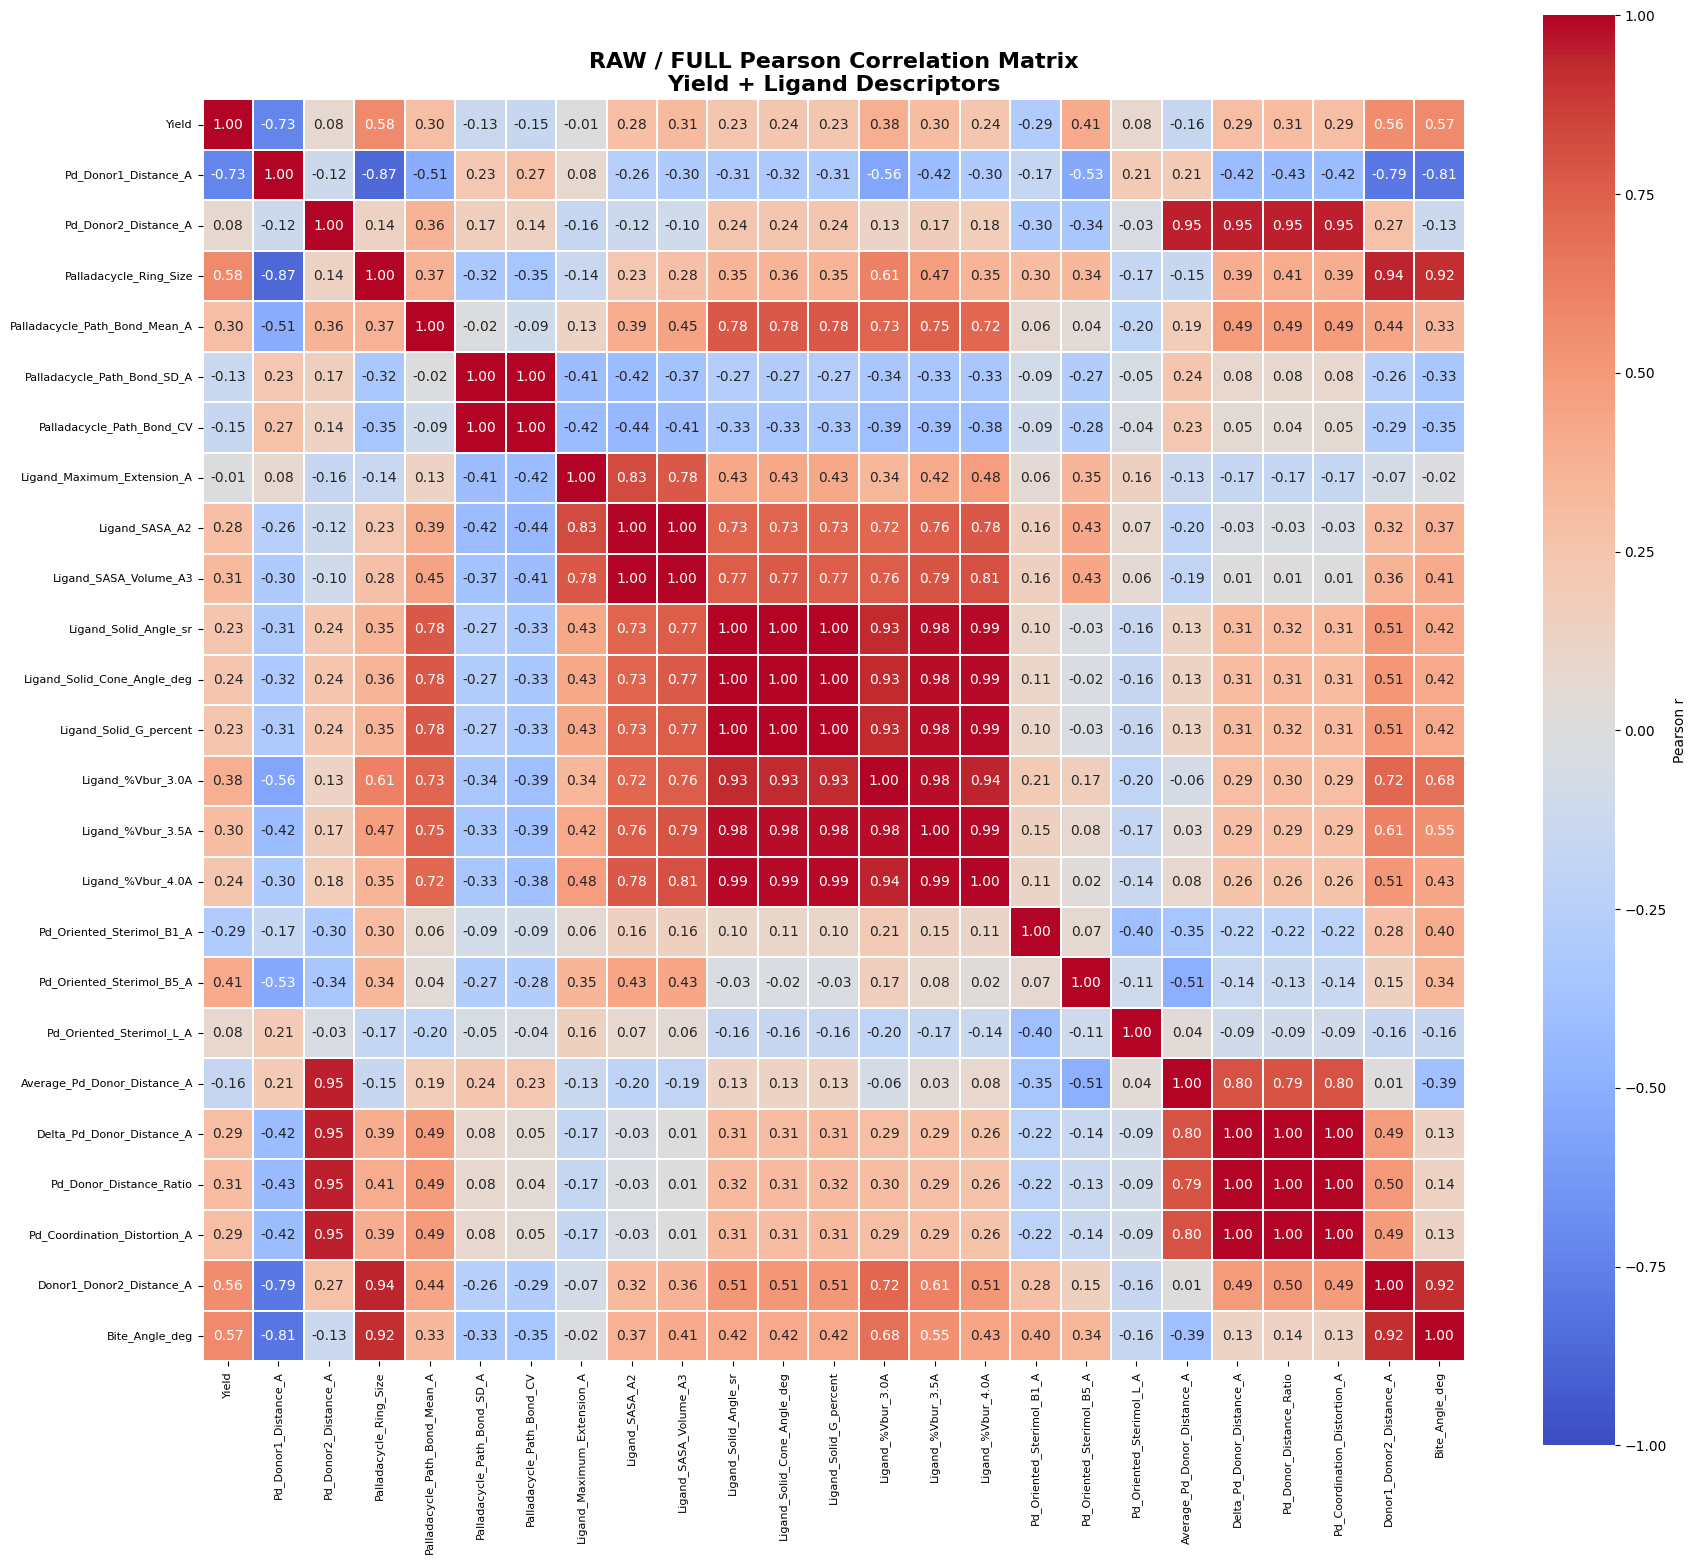

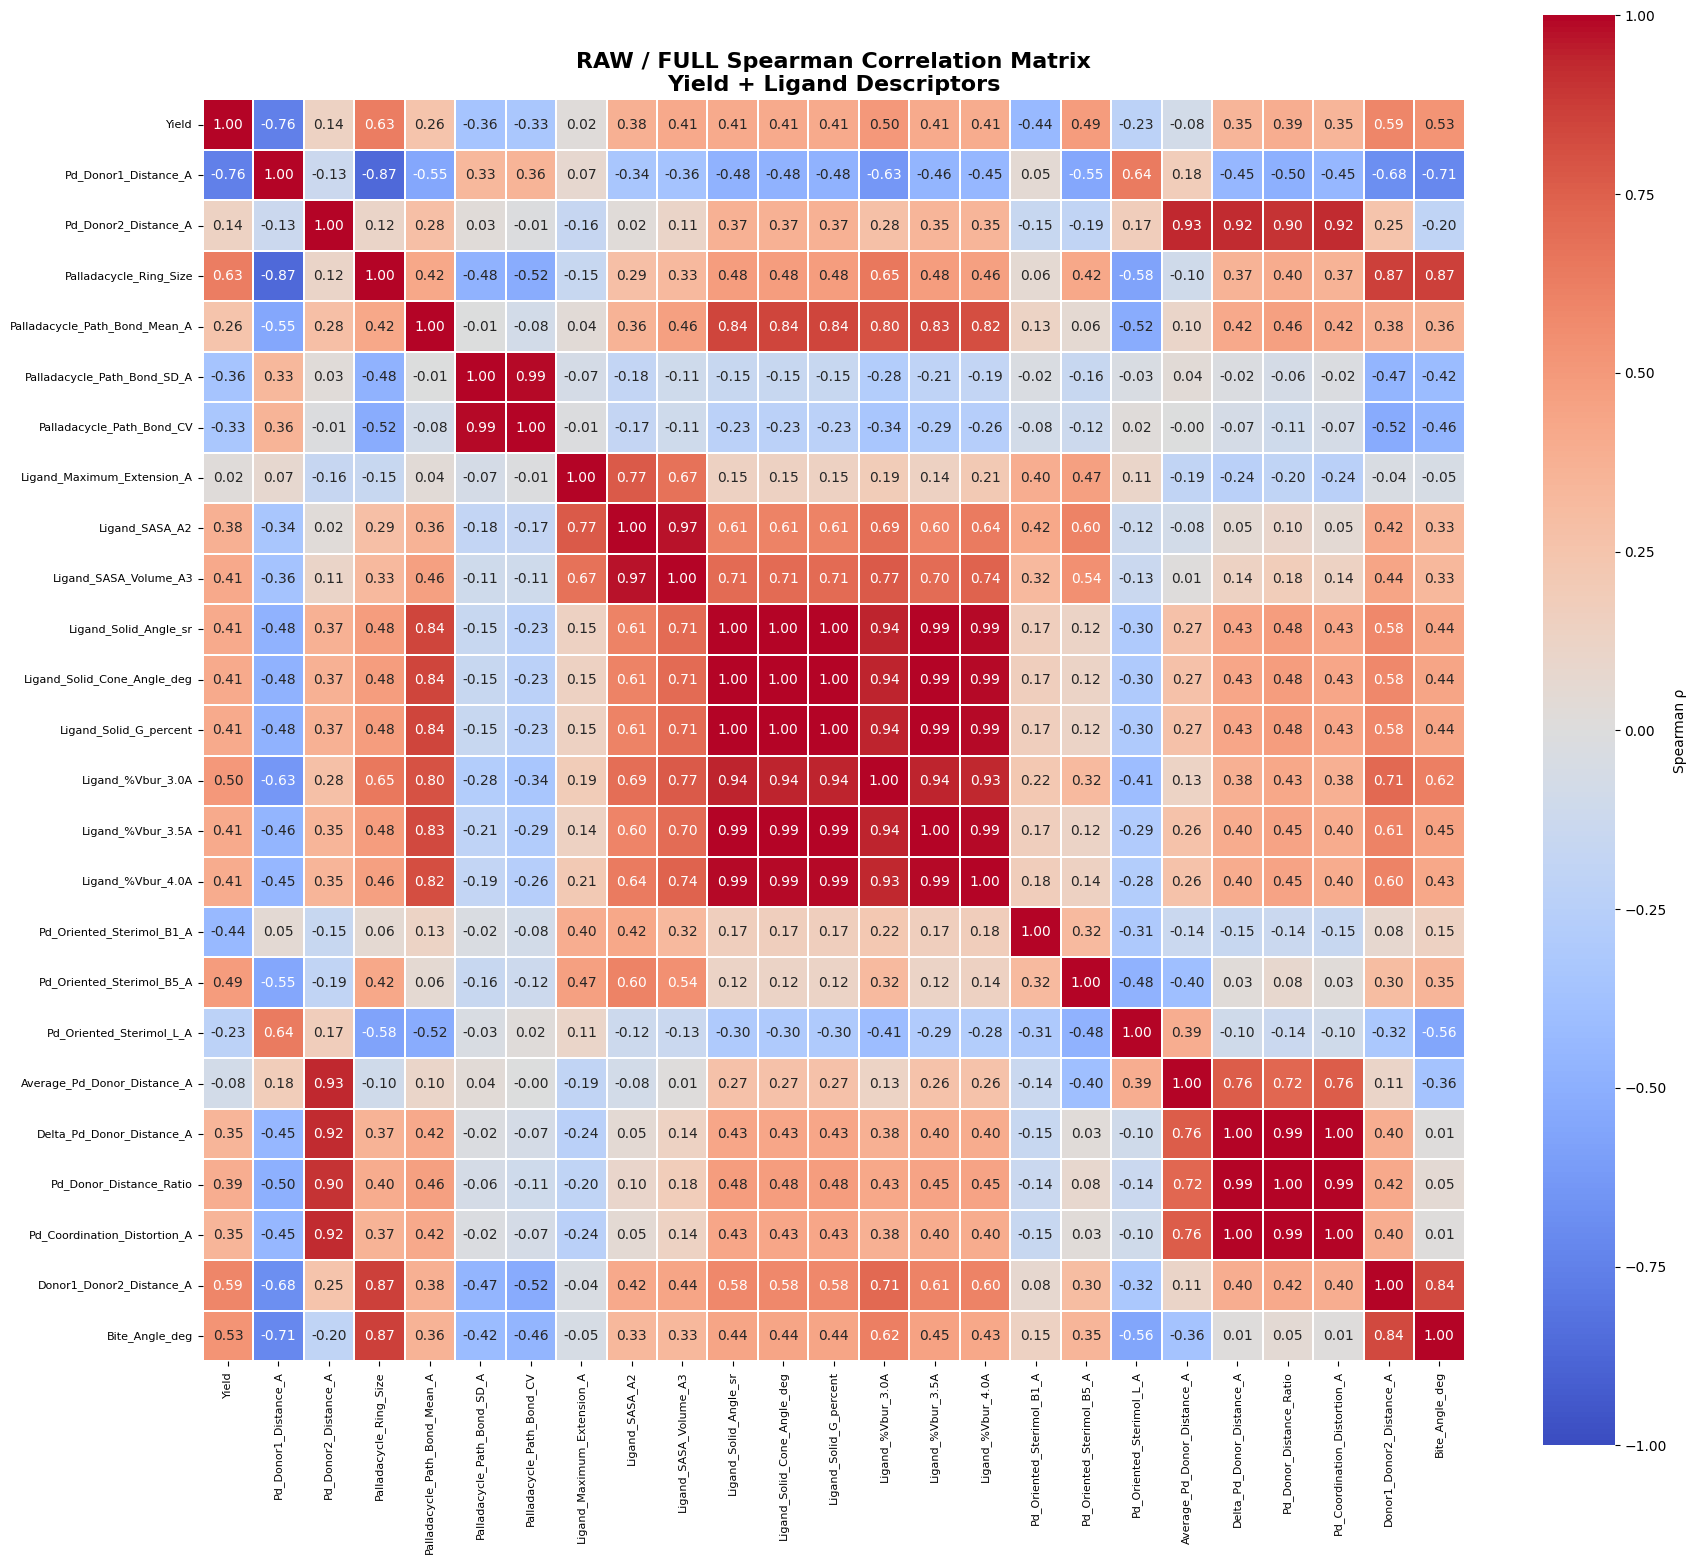



FINAL VERIFICATION
✓ Pd_Oriented_Sterimol_B1_A → Pearson + Spearman RAW/FULL
✓ Pd_Oriented_Sterimol_B5_A → Pearson + Spearman RAW/FULL
✓ Pd_Oriented_Sterimol_L_A → Pearson + Spearman RAW/FULL
✗ Ligand_Distal_Volume_Outside_3.5A_A3 → NOT in RAW/FULL matrix
✗ Ligand_Distal_Volume_Fraction_Outside_3.5A → NOT in RAW/FULL matrix
✗ Ligand_Pint → NOT in RAW/FULL matrix
✗ Ligand_Molecular_Volume_A3 → NOT in RAW/FULL matrix


RAW/FULL Excel:
/content/drive/MyDrive/Pd_gamma_arylation_RESULTS/Pd_gamma_arylation_RAW_FULL_Correlation.xlsx


No IQR/MAD outlier filtering was used.
No numerical-range filtering was used.
Large values such as 60–80 or 140–200 were NOT removed merely because of their scale.
Palladacycle_Path_Atom_Count was excluded.
NBO descriptors were excluded.
Sterimol B1, B5 and L were explicitly checked.
Distal Volume was explicitly checked.

RAW / FULL CORRELATION ANALYSIS COMPLETE


In [4]:
# ============================================================
# RAW / FULL CORRELATION MATRIX
# ============================================================
#
# PURPOSE:
#   Pearson + Spearman correlation using ALL VALID RAW DESCRIPTORS
#
# IMPORTANT:
#   - NO IQR OUTLIER REMOVAL
#   - NO MAD OUTLIER REMOVAL
#   - NO range-based removal
#   - NO scaling/normalization
#   - Sterimol B1, B5 and L are retained
#   - Distal Volume is retained
#   - P_int is retained
#   - Molecular Volume is retained
#   - Large numerical ranges are NOT a reason for exclusion
#   - Palladacycle_Path_Atom_Count is excluded
#   - NBO is excluded
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr


# ============================================================
# 1. CHECK MASTER DATAFRAME
# ============================================================

if "master_df" not in globals():

    raise NameError(
        "master_df was not found. "
        "Please run the descriptor-calculation sections first."
    )


# Work from the complete raw descriptor dataframe
raw_df = master_df.copy()


print("\n")
print("=" * 100)
print("RAW / FULL CORRELATION ANALYSIS")
print("=" * 100)

print(
    "Number of ligands:",
    len(raw_df)
)


# ============================================================
# 2. YIELD
# ============================================================

YIELD_DATA = {

    "L7": 0,
    "L8": 0,
    "L9": 0,
    "L10": 0,
    "L11": 0,
    "L12": 0,
    "L13": 0,
    "L14": 0,
    "L15": 0,

    "L16": 12,
    "L17": 53,
    "L18": 46,
    "L19": 67,
    "L20": 40,
    "L21": 31,

    "L22": 0,
    "L23": 0,
    "L24": 0,
    "L25": 0
}


# ------------------------------------------------------------
# Find ligand identifier column
# ------------------------------------------------------------

if "Ligand" in raw_df.columns:

    ligand_column = "Ligand"

elif "Ligand_ID" in raw_df.columns:

    ligand_column = "Ligand_ID"

else:

    raise KeyError(
        "Neither 'Ligand' nor 'Ligand_ID' was found in master_df."
    )


# ------------------------------------------------------------
# Assign Yield directly from L7-L25
# ------------------------------------------------------------

raw_df["Yield"] = raw_df[
    ligand_column
].astype(str).map(YIELD_DATA)


# ------------------------------------------------------------
# Verify Yield
# ------------------------------------------------------------

if raw_df["Yield"].isna().any():

    missing_ligands = raw_df.loc[
        raw_df["Yield"].isna(),
        ligand_column
    ].tolist()

    raise ValueError(
        "Yield is missing for ligand(s): "
        + str(missing_ligands)
    )


print(
    "\nYield successfully assigned."
)

print(
    raw_df[
        [
            ligand_column,
            "Yield"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 3. BUILD NUMERIC RAW DATASET
# ============================================================

numeric_raw = pd.DataFrame(
    index=raw_df.index
)


# ------------------------------------------------------------
# Yield first
# ------------------------------------------------------------

numeric_raw["Yield"] = pd.to_numeric(
    raw_df["Yield"],
    errors="coerce"
)


# ------------------------------------------------------------
# Columns that are NOT predictors
# ------------------------------------------------------------

EXCLUDE_FROM_CORRELATION = {

    # --------------------------------------------------------
    # Identification
    # --------------------------------------------------------

    "Ligand",
    "Ligand_ID",
    "XYZ_File",
    "Filename",
    "File",
    "Warnings",
    "Overall_Status",

    # --------------------------------------------------------
    # Atom indices / bookkeeping
    # --------------------------------------------------------

    "Pd_Atom",
    "Ligand_Start_Atom",
    "Donor1_Atom",
    "Donor2_Atom",

    "N_Atoms",
    "Total_Atoms",
    "Ligand_Atom_Count",

    "Number_of_Donor_Candidates",
    "Number_of_Qualifying_Pd_Donors",

    # --------------------------------------------------------
    # Coordination cutoff/settings
    # --------------------------------------------------------

    "Pd_Donor_Min_A",
    "Pd_Donor_Max_A",

    # --------------------------------------------------------
    # Pyramidalization QC
    # --------------------------------------------------------

    "Donor1_Pyramidalization_Neighbor_Count",
    "Donor2_Pyramidalization_Neighbor_Count",

    # --------------------------------------------------------
    # xTB metadata/settings
    # --------------------------------------------------------

    "XTB_Charge",
    "XTB_N_Unpaired",
    "XTB_Method",

    "XTB_Charge_Sum",

    # --------------------------------------------------------
    # Duplicate descriptor
    #
    # This is mathematically identical to the project-defined
    # Palladacycle_Ring_Size.
    # --------------------------------------------------------

    "Palladacycle_Path_Atom_Count",

    # --------------------------------------------------------
    # Categorical palladacycle descriptors
    # --------------------------------------------------------

    "Palladacycle_Type",
    "Expected_Palladacycle_Type",
    "Palladacycle_Type_Check",

    # ligand path is text
    "Palladacycle_Ligand_Path",

    # --------------------------------------------------------
    # NBO
    #
    # NBO is NOT included in this analysis.
    # --------------------------------------------------------

    "NBO_Donor1_to_Pd_E2_kcal",
    "NBO_Donor2_to_Pd_E2_kcal",
    "NBO_Total_Ligand_to_Pd_E2_kcal",
    "NBO_Max_Ligand_to_Pd_E2_kcal",
    "NBO_Donor_Orbital_Gap_eV"
}


# ============================================================
# 4. ADD ALL NUMERIC DESCRIPTORS
# ============================================================

for column in raw_df.columns:

    if column in EXCLUDE_FROM_CORRELATION:

        continue


    if column == "Yield":

        continue


    converted = pd.to_numeric(
        raw_df[column],
        errors="coerce"
    )


    # --------------------------------------------------------
    # Include descriptor if it has at least 3 valid values
    # --------------------------------------------------------

    if converted.notna().sum() >= 3:

        numeric_raw[column] = converted


# ============================================================
# 5. REMOVE ONLY CONSTANT DESCRIPTORS
# ============================================================
#
# A constant descriptor cannot have a correlation.
#
# IMPORTANT:
# This is NOT outlier filtering.
# This is NOT range filtering.
# ============================================================

constant_columns = []


for column in numeric_raw.columns:

    if column == "Yield":

        continue


    valid_values = numeric_raw[
        column
    ].dropna()


    if valid_values.nunique() <= 1:

        constant_columns.append(
            column
        )


if constant_columns:

    print("\nConstant descriptors removed:")

    for column in constant_columns:

        print(
            "  ",
            column
        )


numeric_raw = numeric_raw.drop(
    columns=constant_columns,
    errors="ignore"
)


# ============================================================
# 6. COMPLETE-DATA CHECK
# ============================================================
#
# For the FULL square matrix we want the same N = 19 for
# every descriptor.
#
# Therefore:
#   - missing-value descriptors are excluded
#   - NO imputation is performed
#   - NO outlier removal is performed
#
# A descriptor with 19 valid values is retained regardless
# of whether its numerical range is 1-2, 60-80, or 140-200.
# ============================================================

complete_columns = []

missing_columns = []


for column in numeric_raw.columns:

    if numeric_raw[
        column
    ].notna().all():

        complete_columns.append(
            column
        )

    else:

        missing_columns.append(
            column
        )


# Yield must be complete
if "Yield" not in complete_columns:

    raise ValueError(
        "Yield contains missing values."
    )


raw_complete_df = numeric_raw[
    complete_columns
].copy()


# ============================================================
# 7. FORCE YIELD TO FIRST COLUMN
# ============================================================

descriptor_columns = [

    column

    for column in raw_complete_df.columns

    if column != "Yield"
]


raw_complete_df = raw_complete_df[
    [
        "Yield"
    ] + descriptor_columns
]


# ============================================================
# 8. IMPORTANT DESCRIPTOR CHECK
# ============================================================

IMPORTANT_DESCRIPTORS = [

    # --------------------------------------------------------
    # Sterimol
    # --------------------------------------------------------

    "Pd_Oriented_Sterimol_B1_A",
    "Pd_Oriented_Sterimol_B5_A",
    "Pd_Oriented_Sterimol_L_A",

    # --------------------------------------------------------
    # Buried volume
    # --------------------------------------------------------

    "Ligand_%Vbur_3.0A",
    "Ligand_%Vbur_3.5A",
    "Ligand_%Vbur_4.0A",
    "Ligand_%Vbur_4.5A",
    "Ligand_%Vbur_5.0A",

    # --------------------------------------------------------
    # Distal / molecular volume
    # --------------------------------------------------------

    "Ligand_Distal_Volume_Outside_3.5A_A3",
    "Ligand_Distal_Volume_Fraction_Outside_3.5A",
    "Ligand_Molecular_Volume_A3",

    # --------------------------------------------------------
    # Surface / dispersion
    # --------------------------------------------------------

    "Ligand_SASA_A2",
    "Ligand_SASA_Volume_A3",
    "Ligand_Pint",

    # --------------------------------------------------------
    # Solid angle
    # --------------------------------------------------------

    "Ligand_Solid_Angle",
    "Ligand_Solid_Cone_Angle_deg",
    "Ligand_G"
]


print("\n")
print("=" * 100)
print("IMPORTANT DESCRIPTOR STATUS")
print("=" * 100)


for column in IMPORTANT_DESCRIPTORS:

    if column in raw_complete_df.columns:

        values = raw_complete_df[
            column
        ]

        print(
            f"✓ {column}"
        )

        print(
            f"    N     = {values.notna().sum()}"
        )

        print(
            f"    Min   = {values.min():.6f}"
        )

        print(
            f"    Max   = {values.max():.6f}"
        )

        print(
            f"    Range = {(values.max() - values.min()):.6f}"
        )

    elif column in raw_df.columns:

        valid_n = pd.to_numeric(
            raw_df[column],
            errors="coerce"
        ).notna().sum()

        print(
            f"⚠ {column}"
        )

        print(
            f"    Present in master_df but "
            f"NOT complete: N={valid_n}/{len(raw_df)}"
        )

    else:

        print(
            f"✗ {column}"
        )

        print(
            "    NOT FOUND in master_df"
        )


# ============================================================
# 9. RAW / FULL PEARSON MATRIX
# ============================================================

pearson_matrix_raw = raw_complete_df.corr(
    method="pearson"
)


# ============================================================
# 10. RAW / FULL SPEARMAN MATRIX
# ============================================================

spearman_matrix_raw = raw_complete_df.corr(
    method="spearman"
)


# ============================================================
# 11. CHECK MATRIX SIZE
# ============================================================

print("\n")
print("=" * 100)
print("RAW / FULL CORRELATION MATRICES")
print("=" * 100)

print(
    "Observations:",
    len(raw_complete_df)
)

print(
    "Variables:",
    len(raw_complete_df.columns)
)

print(
    "Pearson matrix:",
    pearson_matrix_raw.shape
)

print(
    "Spearman matrix:",
    spearman_matrix_raw.shape
)


# ============================================================
# 12. YIELD vs EVERY RAW DESCRIPTOR
# ============================================================

yield_results = []


for descriptor in descriptor_columns:

    x = raw_complete_df[
        descriptor
    ].to_numpy(
        dtype=float
    )

    y = raw_complete_df[
        "Yield"
    ].to_numpy(
        dtype=float
    )


    if (
        len(x) >= 3
        and np.std(x) > 0
        and np.std(y) > 0
    ):

        r, p_r = pearsonr(
            x,
            y
        )

        rho, p_s = spearmanr(
            x,
            y
        )


        yield_results.append({

            "Descriptor":
                descriptor,

            "N":
                len(x),

            "Pearson_r":
                r,

            "Pearson_p":
                p_r,

            "Spearman_rho":
                rho,

            "Spearman_p":
                p_s,

            "Abs_Pearson_r":
                abs(r),

            "Abs_Spearman_rho":
                abs(rho),

            "Mean_Abs_Correlation":
                (
                    abs(r)
                    +
                    abs(rho)
                )
                / 2.0
        })


yield_correlation_df = pd.DataFrame(
    yield_results
)


# ============================================================
# 13. RANK BY MEAN ABSOLUTE CORRELATION
# ============================================================

yield_correlation_df = (

    yield_correlation_df

    .sort_values(
        "Mean_Abs_Correlation",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 14. TOP 5 PEARSON
# ============================================================

top5_pearson = (

    yield_correlation_df

    .sort_values(
        "Abs_Pearson_r",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. TOP 5 SPEARMAN
# ============================================================

top5_spearman = (

    yield_correlation_df

    .sort_values(
        "Abs_Spearman_rho",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 16. TOP 5 COMBINED
# ============================================================

top5_combined = (

    yield_correlation_df

    .sort_values(
        "Mean_Abs_Correlation",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 17. PRINT FULL YIELD RANKING
# ============================================================

print("\n")
print("=" * 100)
print("YIELD vs RAW / FULL DESCRIPTORS")
print("=" * 100)

display(
    yield_correlation_df
)


# ============================================================
# 18. PRINT STERIMOL RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("STERIMOL — RAW / FULL YIELD CORRELATION")
print("=" * 100)


sterimol_results = yield_correlation_df[
    yield_correlation_df[
        "Descriptor"
    ].isin(
        [
            "Pd_Oriented_Sterimol_B1_A",
            "Pd_Oriented_Sterimol_B5_A",
            "Pd_Oriented_Sterimol_L_A"
        ]
    )
].copy()


if len(sterimol_results) > 0:

    display(
        sterimol_results
    )

else:

    print(
        "WARNING: Sterimol descriptors are not in "
        "the RAW/FULL correlation dataframe."
    )


# ============================================================
# 19. PRINT DISTAL VOLUME RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("DISTAL VOLUME — RAW / FULL YIELD CORRELATION")
print("=" * 100)


distal_results = yield_correlation_df[
    yield_correlation_df[
        "Descriptor"
    ].isin(
        [
            "Ligand_Distal_Volume_Outside_3.5A_A3",
            "Ligand_Distal_Volume_Fraction_Outside_3.5A"
        ]
    )
].copy()


if len(distal_results) > 0:

    display(
        distal_results
    )

else:

    print(
        "WARNING: Distal Volume descriptors are not in "
        "the RAW/FULL correlation dataframe."
    )


# ============================================================
# 20. PEARSON HEATMAP
# ============================================================

pearson_png = os.path.join(
    OUTPUT_FOLDER,
    "Pearson_RAW_FULL_Correlation_Matrix.png"
)


plt.figure(
    figsize=(
        max(18, len(pearson_matrix_raw) * 0.55),
        max(16, len(pearson_matrix_raw) * 0.55)
    )
)


sns.heatmap(

    pearson_matrix_raw,

    annot=(
        len(pearson_matrix_raw)
        <= 30
    ),

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    vmin=-1,

    vmax=1,

    square=True,

    linewidths=0.35,

    cbar_kws={
        "label":
            "Pearson r"
    }
)


plt.title(
    "RAW / FULL Pearson Correlation Matrix\n"
    "Yield + Ligand Descriptors",
    fontsize=16,
    fontweight="bold"
)


plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    pearson_png,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 21. SPEARMAN HEATMAP
# ============================================================

spearman_png = os.path.join(
    OUTPUT_FOLDER,
    "Spearman_RAW_FULL_Correlation_Matrix.png"
)


plt.figure(
    figsize=(
        max(18, len(spearman_matrix_raw) * 0.55),
        max(16, len(spearman_matrix_raw) * 0.55)
    )
)


sns.heatmap(

    spearman_matrix_raw,

    annot=(
        len(spearman_matrix_raw)
        <= 30
    ),

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    vmin=-1,

    vmax=1,

    square=True,

    linewidths=0.35,

    cbar_kws={
        "label":
            "Spearman ρ"
    }
)


plt.title(
    "RAW / FULL Spearman Correlation Matrix\n"
    "Yield + Ligand Descriptors",
    fontsize=16,
    fontweight="bold"
)


plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    spearman_png,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 22. SAVE EXCEL
# ============================================================

RAW_CORRELATION_EXCEL = os.path.join(
    OUTPUT_FOLDER,
    "Pd_gamma_arylation_RAW_FULL_Correlation.xlsx"
)


with pd.ExcelWriter(
    RAW_CORRELATION_EXCEL,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # Raw numerical data used for correlation
    # --------------------------------------------------------

    raw_complete_df.to_excel(
        writer,
        sheet_name="RAW_CORRELATION_DATA",
        index=False
    )


    # --------------------------------------------------------
    # Full square matrices
    # --------------------------------------------------------

    pearson_matrix_raw.to_excel(
        writer,
        sheet_name="Pearson_RAW_FULL"
    )


    spearman_matrix_raw.to_excel(
        writer,
        sheet_name="Spearman_RAW_FULL"
    )


    # --------------------------------------------------------
    # Yield ranking
    # --------------------------------------------------------

    yield_correlation_df.to_excel(
        writer,
        sheet_name="YIELD_RAW_RANKING",
        index=False
    )


    # --------------------------------------------------------
    # Top 5
    # --------------------------------------------------------

    top5_pearson.to_excel(
        writer,
        sheet_name="TOP5_PEARSON",
        index=False
    )


    top5_spearman.to_excel(
        writer,
        sheet_name="TOP5_SPEARMAN",
        index=False
    )


    top5_combined.to_excel(
        writer,
        sheet_name="TOP5_COMBINED",
        index=False
    )


    # --------------------------------------------------------
    # Sterimol
    # --------------------------------------------------------

    sterimol_results.to_excel(
        writer,
        sheet_name="STERIMOL_YIELD",
        index=False
    )


    # --------------------------------------------------------
    # Distal volume
    # --------------------------------------------------------

    distal_results.to_excel(
        writer,
        sheet_name="DISTAL_VOLUME_YIELD",
        index=False
    )


    # --------------------------------------------------------
    # Missing descriptors
    # --------------------------------------------------------

    pd.DataFrame({

        "Descriptor":
            missing_columns

    }).to_excel(
        writer,
        sheet_name="MISSING_DESCRIPTORS",
        index=False
    )


    # --------------------------------------------------------
    # Constant descriptors
    # --------------------------------------------------------

    pd.DataFrame({

        "Descriptor":
            constant_columns

    }).to_excel(
        writer,
        sheet_name="CONSTANT_DESCRIPTORS",
        index=False
    )


# ============================================================
# 23. FINAL VERIFICATION
# ============================================================

print("\n")
print("=" * 100)
print("FINAL VERIFICATION")
print("=" * 100)


for descriptor in [

    "Pd_Oriented_Sterimol_B1_A",
    "Pd_Oriented_Sterimol_B5_A",
    "Pd_Oriented_Sterimol_L_A",

    "Ligand_Distal_Volume_Outside_3.5A_A3",

    "Ligand_Distal_Volume_Fraction_Outside_3.5A",

    "Ligand_Pint",

    "Ligand_Molecular_Volume_A3"

]:

    if descriptor in pearson_matrix_raw.columns:

        print(
            f"✓ {descriptor} "
            "→ Pearson + Spearman RAW/FULL"
        )

    else:

        print(
            f"✗ {descriptor} "
            "→ NOT in RAW/FULL matrix"
        )


print("\n")
print(
    "RAW/FULL Excel:"
)

print(
    RAW_CORRELATION_EXCEL
)


print("\n")
print(
    "No IQR/MAD outlier filtering was used."
)

print(
    "No numerical-range filtering was used."
)

print(
    "Large values such as 60–80 or 140–200 "
    "were NOT removed merely because of their scale."
)

print(
    "Palladacycle_Path_Atom_Count was excluded."
)

print(
    "NBO descriptors were excluded."
)

print(
    "Sterimol B1, B5 and L were explicitly checked."
)

print(
    "Distal Volume was explicitly checked."
)

print("\n" + "=" * 100)
print("RAW / FULL CORRELATION ANALYSIS COMPLETE")
print("=" * 100)



RAW / FULL CORRELATION ANALYSIS
Number of ligands: 19

Yield successfully assigned.
Ligand  Yield
    L7      0
    L8      0
    L9      0
   L10      0
   L11      0
   L12      0
   L13      0
   L14      0
   L15      0
   L16     12
   L17     53
   L18     46
   L19     67
   L20     40
   L21     31
   L22      0
   L23      0
   L24      0
   L25      0


IMPORTANT DESCRIPTOR STATUS
✓ Pd_Oriented_Sterimol_B1_A
    N     = 19
    Min   = 1.689513
    Max   = 2.654875
    Range = 0.965362
✓ Pd_Oriented_Sterimol_B5_A
    N     = 19
    Min   = 5.326594
    Max   = 8.664630
    Range = 3.338036
✓ Pd_Oriented_Sterimol_L_A
    N     = 19
    Min   = 7.190173
    Max   = 8.057538
    Range = 0.867365
✓ Ligand_%Vbur_3.0A
    N     = 19
    Min   = 32.923309
    Max   = 46.174762
    Range = 13.251453
✓ Ligand_%Vbur_3.5A
    N     = 19
    Min   = 30.457394
    Max   = 45.060334
    Range = 14.602940
✓ Ligand_%Vbur_4.0A
    N     = 19
    Min   = 27.269024
    Max   = 44.014183
    Ra

,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Pearson_r,Abs_Spearman_rho,Mean_Abs_Correlation
0,Pd_Donor1_Distance_A,19,-0.728209,0.000408,-0.757001,0.000175,0.728209,0.757001,0.742605
1,Palladacycle_Ring_Size,19,0.575878,0.009871,0.629801,0.003854,0.575878,0.629801,0.602839
2,Donor1_Donor2_Distance_A,19,0.557718,0.013095,0.589015,0.007966,0.557718,0.589015,0.573367
3,Bite_Angle_deg,19,0.573648,0.010228,0.525223,0.020932,0.573648,0.525223,0.549436
4,Pd_Oriented_Sterimol_B5_A,19,0.409090,0.082005,0.486948,0.034478,0.409090,0.486948,0.448019
5,Ligand_%Vbur_3.0A,19,0.383662,0.104895,0.503959,0.027804,0.383662,0.503959,0.443810
6,Ligand_SASA_Volume_A3,19,0.313902,0.190619,0.414650,0.077534,0.313902,0.414650,0.364276
7,Pd_Oriented_Sterimol_B1_A,19,-0.291764,0.225504,-0.435914,0.062086,0.291764,0.435914,0.363839
8,Ligand_%Vbur_3.5A,19,0.304010,0.205730,0.412523,0.079222,0.304010,0.412523,0.358267
9,Pd_Donor_Distance_Ratio,19,0.305549,0.203328,0.393386,0.095656,0.305549,0.393386,0.349467




STERIMOL — RAW / FULL YIELD CORRELATION


,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Pearson_r,Abs_Spearman_rho,Mean_Abs_Correlation
4,Pd_Oriented_Sterimol_B5_A,19,0.409090,0.082005,0.486948,0.034478,0.409090,0.486948,0.448019
7,Pd_Oriented_Sterimol_B1_A,19,-0.291764,0.225504,-0.435914,0.062086,0.291764,0.435914,0.363839
20,Pd_Oriented_Sterimol_L_A,19,0.081232,0.740954,-0.225399,0.353506,0.081232,0.225399,0.153316




DISTAL VOLUME — RAW / FULL YIELD CORRELATION


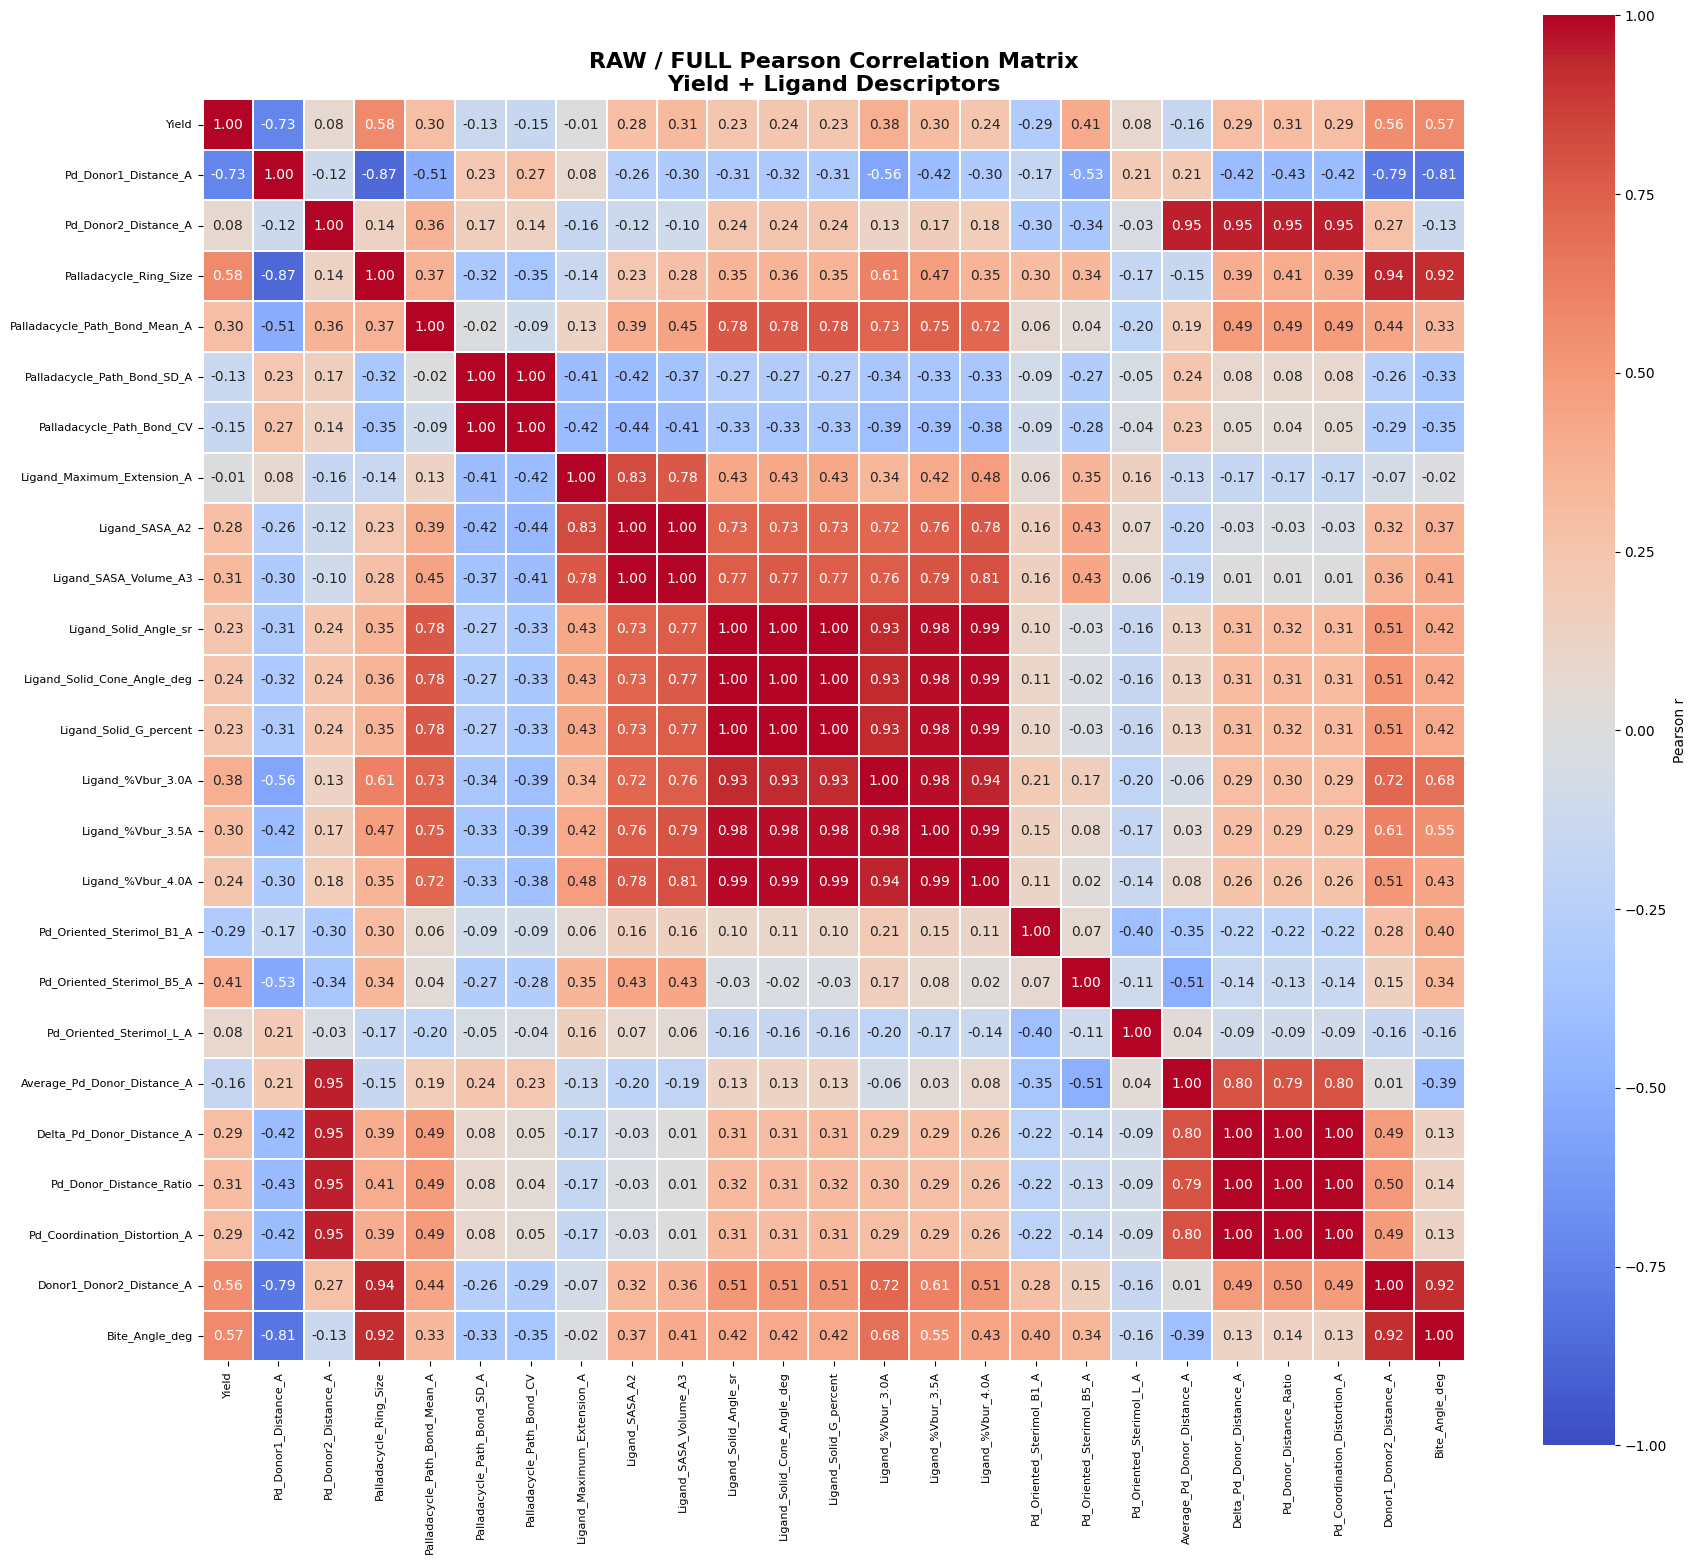

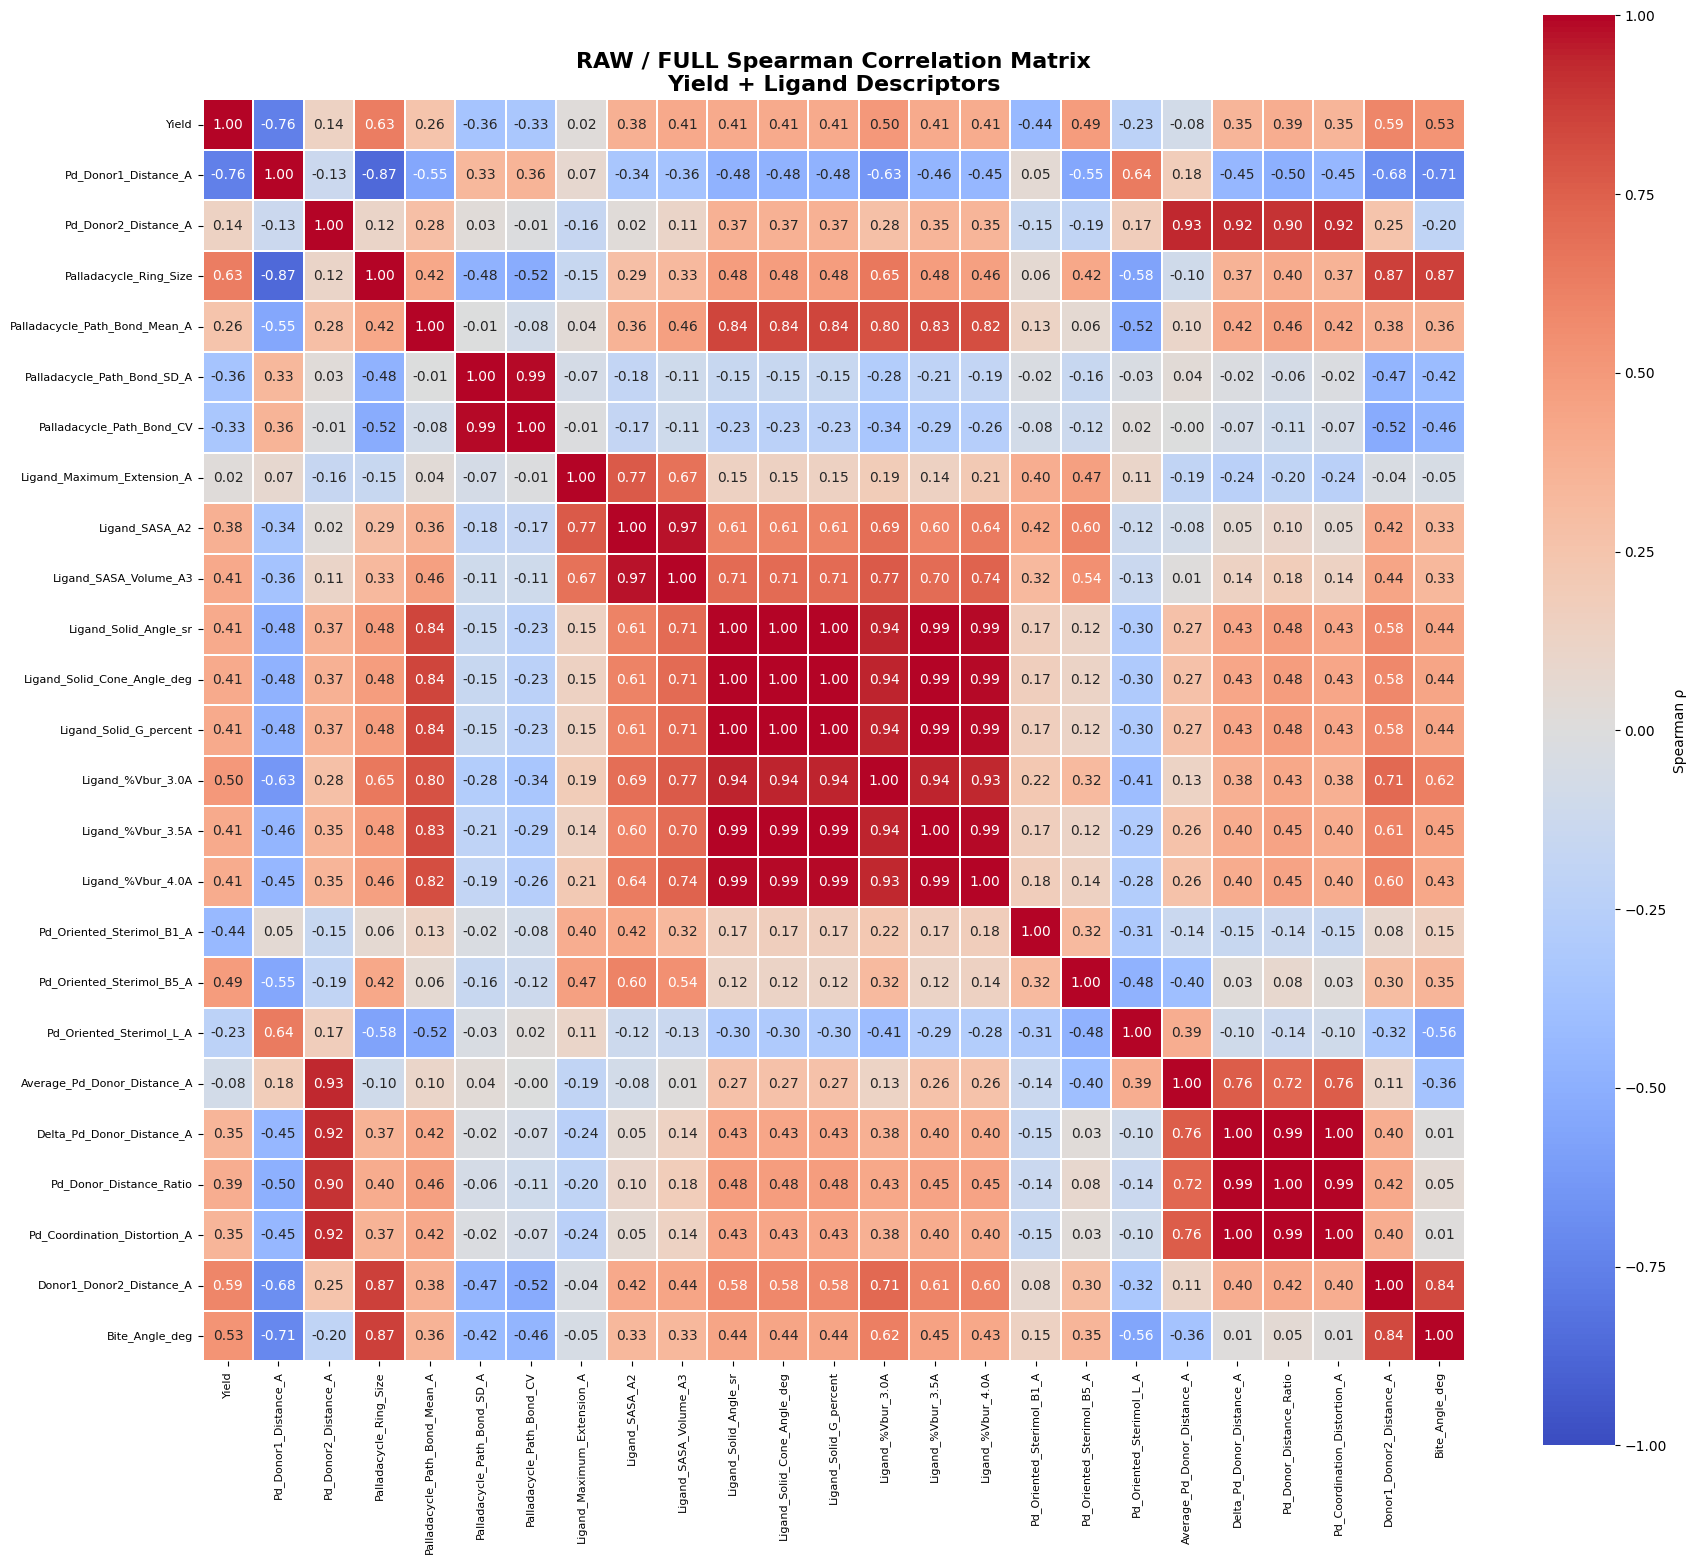



FINAL VERIFICATION
✓ Pd_Oriented_Sterimol_B1_A → Pearson + Spearman RAW/FULL
✓ Pd_Oriented_Sterimol_B5_A → Pearson + Spearman RAW/FULL
✓ Pd_Oriented_Sterimol_L_A → Pearson + Spearman RAW/FULL
✗ Ligand_Distal_Volume_Outside_3.5A_A3 → NOT in RAW/FULL matrix
✗ Ligand_Distal_Volume_Fraction_Outside_3.5A → NOT in RAW/FULL matrix
✗ Ligand_Pint → NOT in RAW/FULL matrix
✗ Ligand_Molecular_Volume_A3 → NOT in RAW/FULL matrix


RAW/FULL Excel:
/content/drive/MyDrive/Pd_gamma_arylation_RESULTS/Pd_gamma_arylation_RAW_FULL_Correlation.xlsx


No IQR/MAD outlier filtering was used.
No numerical-range filtering was used.
Large values such as 60–80 or 140–200 were NOT removed merely because of their scale.
Palladacycle_Path_Atom_Count was excluded.
NBO descriptors were excluded.
Sterimol B1, B5 and L were explicitly checked.
Distal Volume was explicitly checked.

RAW / FULL CORRELATION ANALYSIS COMPLETE


In [3]:
# ============================================================
# RAW / FULL CORRELATION MATRIX
# ============================================================
#
# PURPOSE:
#   Pearson + Spearman correlation using ALL VALID RAW DESCRIPTORS
#
# IMPORTANT:
#   - NO IQR OUTLIER REMOVAL
#   - NO MAD OUTLIER REMOVAL
#   - NO range-based removal
#   - NO scaling/normalization
#   - Sterimol B1, B5 and L are retained
#   - Distal Volume is retained
#   - P_int is retained
#   - Molecular Volume is retained
#   - Large numerical ranges are NOT a reason for exclusion
#   - Palladacycle_Path_Atom_Count is excluded
#   - NBO is excluded
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr


# ============================================================
# 1. CHECK MASTER DATAFRAME
# ============================================================

if "master_df" not in globals():

    raise NameError(
        "master_df was not found. "
        "Please run the descriptor-calculation sections first."
    )


# Work from the complete raw descriptor dataframe
raw_df = master_df.copy()


print("\n")
print("=" * 100)
print("RAW / FULL CORRELATION ANALYSIS")
print("=" * 100)

print(
    "Number of ligands:",
    len(raw_df)
)


# ============================================================
# 2. YIELD
# ============================================================

YIELD_DATA = {

    "L7": 0,
    "L8": 0,
    "L9": 0,
    "L10": 0,
    "L11": 0,
    "L12": 0,
    "L13": 0,
    "L14": 0,
    "L15": 0,

    "L16": 12,
    "L17": 53,
    "L18": 46,
    "L19": 67,
    "L20": 40,
    "L21": 31,

    "L22": 0,
    "L23": 0,
    "L24": 0,
    "L25": 0
}


# ------------------------------------------------------------
# Find ligand identifier column
# ------------------------------------------------------------

if "Ligand" in raw_df.columns:

    ligand_column = "Ligand"

elif "Ligand_ID" in raw_df.columns:

    ligand_column = "Ligand_ID"

else:

    raise KeyError(
        "Neither 'Ligand' nor 'Ligand_ID' was found in master_df."
    )


# ------------------------------------------------------------
# Assign Yield directly from L7-L25
# ------------------------------------------------------------

raw_df["Yield"] = raw_df[
    ligand_column
].astype(str).map(YIELD_DATA)


# ------------------------------------------------------------
# Verify Yield
# ------------------------------------------------------------

if raw_df["Yield"].isna().any():

    missing_ligands = raw_df.loc[
        raw_df["Yield"].isna(),
        ligand_column
    ].tolist()

    raise ValueError(
        "Yield is missing for ligand(s): "
        + str(missing_ligands)
    )


print(
    "\nYield successfully assigned."
)

print(
    raw_df[
        [
            ligand_column,
            "Yield"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 3. BUILD NUMERIC RAW DATASET
# ============================================================

numeric_raw = pd.DataFrame(
    index=raw_df.index
)


# ------------------------------------------------------------
# Yield first
# ------------------------------------------------------------

numeric_raw["Yield"] = pd.to_numeric(
    raw_df["Yield"],
    errors="coerce"
)


# ------------------------------------------------------------
# Columns that are NOT predictors
# ------------------------------------------------------------

EXCLUDE_FROM_CORRELATION = {

    # --------------------------------------------------------
    # Identification
    # --------------------------------------------------------

    "Ligand",
    "Ligand_ID",
    "XYZ_File",
    "Filename",
    "File",
    "Warnings",
    "Overall_Status",

    # --------------------------------------------------------
    # Atom indices / bookkeeping
    # --------------------------------------------------------

    "Pd_Atom",
    "Ligand_Start_Atom",
    "Donor1_Atom",
    "Donor2_Atom",

    "N_Atoms",
    "Total_Atoms",
    "Ligand_Atom_Count",

    "Number_of_Donor_Candidates",
    "Number_of_Qualifying_Pd_Donors",

    # --------------------------------------------------------
    # Coordination cutoff/settings
    # --------------------------------------------------------

    "Pd_Donor_Min_A",
    "Pd_Donor_Max_A",

    # --------------------------------------------------------
    # Pyramidalization QC
    # --------------------------------------------------------

    "Donor1_Pyramidalization_Neighbor_Count",
    "Donor2_Pyramidalization_Neighbor_Count",

    # --------------------------------------------------------
    # xTB metadata/settings
    # --------------------------------------------------------

    "XTB_Charge",
    "XTB_N_Unpaired",
    "XTB_Method",

    "XTB_Charge_Sum",

    # --------------------------------------------------------
    # Duplicate descriptor
    #
    # This is mathematically identical to the project-defined
    # Palladacycle_Ring_Size.
    # --------------------------------------------------------

    "Palladacycle_Path_Atom_Count",

    # --------------------------------------------------------
    # Categorical palladacycle descriptors
    # --------------------------------------------------------

    "Palladacycle_Type",
    "Expected_Palladacycle_Type",
    "Palladacycle_Type_Check",

    # ligand path is text
    "Palladacycle_Ligand_Path",

    # --------------------------------------------------------
    # NBO
    #
    # NBO is NOT included in this analysis.
    # --------------------------------------------------------

    "NBO_Donor1_to_Pd_E2_kcal",
    "NBO_Donor2_to_Pd_E2_kcal",
    "NBO_Total_Ligand_to_Pd_E2_kcal",
    "NBO_Max_Ligand_to_Pd_E2_kcal",
    "NBO_Donor_Orbital_Gap_eV"
}


# ============================================================
# 4. ADD ALL NUMERIC DESCRIPTORS
# ============================================================

for column in raw_df.columns:

    if column in EXCLUDE_FROM_CORRELATION:

        continue


    if column == "Yield":

        continue


    converted = pd.to_numeric(
        raw_df[column],
        errors="coerce"
    )


    # --------------------------------------------------------
    # Include descriptor if it has at least 3 valid values
    # --------------------------------------------------------

    if converted.notna().sum() >= 3:

        numeric_raw[column] = converted


# ============================================================
# 5. REMOVE ONLY CONSTANT DESCRIPTORS
# ============================================================
#
# A constant descriptor cannot have a correlation.
#
# IMPORTANT:
# This is NOT outlier filtering.
# This is NOT range filtering.
# ============================================================

constant_columns = []


for column in numeric_raw.columns:

    if column == "Yield":

        continue


    valid_values = numeric_raw[
        column
    ].dropna()


    if valid_values.nunique() <= 1:

        constant_columns.append(
            column
        )


if constant_columns:

    print("\nConstant descriptors removed:")

    for column in constant_columns:

        print(
            "  ",
            column
        )


numeric_raw = numeric_raw.drop(
    columns=constant_columns,
    errors="ignore"
)


# ============================================================
# 6. COMPLETE-DATA CHECK
# ============================================================
#
# For the FULL square matrix we want the same N = 19 for
# every descriptor.
#
# Therefore:
#   - missing-value descriptors are excluded
#   - NO imputation is performed
#   - NO outlier removal is performed
#
# A descriptor with 19 valid values is retained regardless
# of whether its numerical range is 1-2, 60-80, or 140-200.
# ============================================================

complete_columns = []

missing_columns = []


for column in numeric_raw.columns:

    if numeric_raw[
        column
    ].notna().all():

        complete_columns.append(
            column
        )

    else:

        missing_columns.append(
            column
        )


# Yield must be complete
if "Yield" not in complete_columns:

    raise ValueError(
        "Yield contains missing values."
    )


raw_complete_df = numeric_raw[
    complete_columns
].copy()


# ============================================================
# 7. FORCE YIELD TO FIRST COLUMN
# ============================================================

descriptor_columns = [

    column

    for column in raw_complete_df.columns

    if column != "Yield"
]


raw_complete_df = raw_complete_df[
    [
        "Yield"
    ] + descriptor_columns
]


# ============================================================
# 8. IMPORTANT DESCRIPTOR CHECK
# ============================================================

IMPORTANT_DESCRIPTORS = [

    # --------------------------------------------------------
    # Sterimol
    # --------------------------------------------------------

    "Pd_Oriented_Sterimol_B1_A",
    "Pd_Oriented_Sterimol_B5_A",
    "Pd_Oriented_Sterimol_L_A",

    # --------------------------------------------------------
    # Buried volume
    # --------------------------------------------------------

    "Ligand_%Vbur_3.0A",
    "Ligand_%Vbur_3.5A",
    "Ligand_%Vbur_4.0A",
    "Ligand_%Vbur_4.5A",
    "Ligand_%Vbur_5.0A",

    # --------------------------------------------------------
    # Distal / molecular volume
    # --------------------------------------------------------

    "Ligand_Distal_Volume_Outside_3.5A_A3",
    "Ligand_Distal_Volume_Fraction_Outside_3.5A",
    "Ligand_Molecular_Volume_A3",

    # --------------------------------------------------------
    # Surface / dispersion
    # --------------------------------------------------------

    "Ligand_SASA_A2",
    "Ligand_SASA_Volume_A3",
    "Ligand_Pint",

    # --------------------------------------------------------
    # Solid angle
    # --------------------------------------------------------

    "Ligand_Solid_Angle",
    "Ligand_Solid_Cone_Angle_deg",
    "Ligand_G"
]


print("\n")
print("=" * 100)
print("IMPORTANT DESCRIPTOR STATUS")
print("=" * 100)


for column in IMPORTANT_DESCRIPTORS:

    if column in raw_complete_df.columns:

        values = raw_complete_df[
            column
        ]

        print(
            f"✓ {column}"
        )

        print(
            f"    N     = {values.notna().sum()}"
        )

        print(
            f"    Min   = {values.min():.6f}"
        )

        print(
            f"    Max   = {values.max():.6f}"
        )

        print(
            f"    Range = {(values.max() - values.min()):.6f}"
        )

    elif column in raw_df.columns:

        valid_n = pd.to_numeric(
            raw_df[column],
            errors="coerce"
        ).notna().sum()

        print(
            f"⚠ {column}"
        )

        print(
            f"    Present in master_df but "
            f"NOT complete: N={valid_n}/{len(raw_df)}"
        )

    else:

        print(
            f"✗ {column}"
        )

        print(
            "    NOT FOUND in master_df"
        )


# ============================================================
# 9. RAW / FULL PEARSON MATRIX
# ============================================================

pearson_matrix_raw = raw_complete_df.corr(
    method="pearson"
)


# ============================================================
# 10. RAW / FULL SPEARMAN MATRIX
# ============================================================

spearman_matrix_raw = raw_complete_df.corr(
    method="spearman"
)


# ============================================================
# 11. CHECK MATRIX SIZE
# ============================================================

print("\n")
print("=" * 100)
print("RAW / FULL CORRELATION MATRICES")
print("=" * 100)

print(
    "Observations:",
    len(raw_complete_df)
)

print(
    "Variables:",
    len(raw_complete_df.columns)
)

print(
    "Pearson matrix:",
    pearson_matrix_raw.shape
)

print(
    "Spearman matrix:",
    spearman_matrix_raw.shape
)


# ============================================================
# 12. YIELD vs EVERY RAW DESCRIPTOR
# ============================================================

yield_results = []


for descriptor in descriptor_columns:

    x = raw_complete_df[
        descriptor
    ].to_numpy(
        dtype=float
    )

    y = raw_complete_df[
        "Yield"
    ].to_numpy(
        dtype=float
    )


    if (
        len(x) >= 3
        and np.std(x) > 0
        and np.std(y) > 0
    ):

        r, p_r = pearsonr(
            x,
            y
        )

        rho, p_s = spearmanr(
            x,
            y
        )


        yield_results.append({

            "Descriptor":
                descriptor,

            "N":
                len(x),

            "Pearson_r":
                r,

            "Pearson_p":
                p_r,

            "Spearman_rho":
                rho,

            "Spearman_p":
                p_s,

            "Abs_Pearson_r":
                abs(r),

            "Abs_Spearman_rho":
                abs(rho),

            "Mean_Abs_Correlation":
                (
                    abs(r)
                    +
                    abs(rho)
                )
                / 2.0
        })


yield_correlation_df = pd.DataFrame(
    yield_results
)


# ============================================================
# 13. RANK BY MEAN ABSOLUTE CORRELATION
# ============================================================

yield_correlation_df = (

    yield_correlation_df

    .sort_values(
        "Mean_Abs_Correlation",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 14. TOP 5 PEARSON
# ============================================================

top5_pearson = (

    yield_correlation_df

    .sort_values(
        "Abs_Pearson_r",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. TOP 5 SPEARMAN
# ============================================================

top5_spearman = (

    yield_correlation_df

    .sort_values(
        "Abs_Spearman_rho",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 16. TOP 5 COMBINED
# ============================================================

top5_combined = (

    yield_correlation_df

    .sort_values(
        "Mean_Abs_Correlation",
        ascending=False
    )

    .head(5)

    .reset_index(
        drop=True
    )
)


# ============================================================
# 17. PRINT FULL YIELD RANKING
# ============================================================

print("\n")
print("=" * 100)
print("YIELD vs RAW / FULL DESCRIPTORS")
print("=" * 100)

display(
    yield_correlation_df
)


# ============================================================
# 18. PRINT STERIMOL RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("STERIMOL — RAW / FULL YIELD CORRELATION")
print("=" * 100)


sterimol_results = yield_correlation_df[
    yield_correlation_df[
        "Descriptor"
    ].isin(
        [
            "Pd_Oriented_Sterimol_B1_A",
            "Pd_Oriented_Sterimol_B5_A",
            "Pd_Oriented_Sterimol_L_A"
        ]
    )
].copy()


if len(sterimol_results) > 0:

    display(
        sterimol_results
    )

else:

    print(
        "WARNING: Sterimol descriptors are not in "
        "the RAW/FULL correlation dataframe."
    )


# ============================================================
# 19. PRINT DISTAL VOLUME RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("DISTAL VOLUME — RAW / FULL YIELD CORRELATION")
print("=" * 100)


distal_results = yield_correlation_df[
    yield_correlation_df[
        "Descriptor"
    ].isin(
        [
            "Ligand_Distal_Volume_Outside_3.5A_A3",
            "Ligand_Distal_Volume_Fraction_Outside_3.5A"
        ]
    )
].copy()


if len(distal_results) > 0:

    display(
        distal_results
    )

else:

    print(
        "WARNING: Distal Volume descriptors are not in "
        "the RAW/FULL correlation dataframe."
    )


# ============================================================
# 20. PEARSON HEATMAP
# ============================================================

pearson_png = os.path.join(
    OUTPUT_FOLDER,
    "Pearson_RAW_FULL_Correlation_Matrix.png"
)


plt.figure(
    figsize=(
        max(18, len(pearson_matrix_raw) * 0.55),
        max(16, len(pearson_matrix_raw) * 0.55)
    )
)


sns.heatmap(

    pearson_matrix_raw,

    annot=(
        len(pearson_matrix_raw)
        <= 30
    ),

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    vmin=-1,

    vmax=1,

    square=True,

    linewidths=0.35,

    cbar_kws={
        "label":
            "Pearson r"
    }
)


plt.title(
    "RAW / FULL Pearson Correlation Matrix\n"
    "Yield + Ligand Descriptors",
    fontsize=16,
    fontweight="bold"
)


plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    pearson_png,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 21. SPEARMAN HEATMAP
# ============================================================

spearman_png = os.path.join(
    OUTPUT_FOLDER,
    "Spearman_RAW_FULL_Correlation_Matrix.png"
)


plt.figure(
    figsize=(
        max(18, len(spearman_matrix_raw) * 0.55),
        max(16, len(spearman_matrix_raw) * 0.55)
    )
)


sns.heatmap(

    spearman_matrix_raw,

    annot=(
        len(spearman_matrix_raw)
        <= 30
    ),

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    vmin=-1,

    vmax=1,

    square=True,

    linewidths=0.35,

    cbar_kws={
        "label":
            "Spearman ρ"
    }
)


plt.title(
    "RAW / FULL Spearman Correlation Matrix\n"
    "Yield + Ligand Descriptors",
    fontsize=16,
    fontweight="bold"
)


plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    spearman_png,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# 22. SAVE EXCEL
# ============================================================

RAW_CORRELATION_EXCEL = os.path.join(
    OUTPUT_FOLDER,
    "Pd_gamma_arylation_RAW_FULL_Correlation.xlsx"
)


with pd.ExcelWriter(
    RAW_CORRELATION_EXCEL,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # Raw numerical data used for correlation
    # --------------------------------------------------------

    raw_complete_df.to_excel(
        writer,
        sheet_name="RAW_CORRELATION_DATA",
        index=False
    )


    # --------------------------------------------------------
    # Full square matrices
    # --------------------------------------------------------

    pearson_matrix_raw.to_excel(
        writer,
        sheet_name="Pearson_RAW_FULL"
    )


    spearman_matrix_raw.to_excel(
        writer,
        sheet_name="Spearman_RAW_FULL"
    )


    # --------------------------------------------------------
    # Yield ranking
    # --------------------------------------------------------

    yield_correlation_df.to_excel(
        writer,
        sheet_name="YIELD_RAW_RANKING",
        index=False
    )


    # --------------------------------------------------------
    # Top 5
    # --------------------------------------------------------

    top5_pearson.to_excel(
        writer,
        sheet_name="TOP5_PEARSON",
        index=False
    )


    top5_spearman.to_excel(
        writer,
        sheet_name="TOP5_SPEARMAN",
        index=False
    )


    top5_combined.to_excel(
        writer,
        sheet_name="TOP5_COMBINED",
        index=False
    )


    # --------------------------------------------------------
    # Sterimol
    # --------------------------------------------------------

    sterimol_results.to_excel(
        writer,
        sheet_name="STERIMOL_YIELD",
        index=False
    )


    # --------------------------------------------------------
    # Distal volume
    # --------------------------------------------------------

    distal_results.to_excel(
        writer,
        sheet_name="DISTAL_VOLUME_YIELD",
        index=False
    )


    # --------------------------------------------------------
    # Missing descriptors
    # --------------------------------------------------------

    pd.DataFrame({

        "Descriptor":
            missing_columns

    }).to_excel(
        writer,
        sheet_name="MISSING_DESCRIPTORS",
        index=False
    )


    # --------------------------------------------------------
    # Constant descriptors
    # --------------------------------------------------------

    pd.DataFrame({

        "Descriptor":
            constant_columns

    }).to_excel(
        writer,
        sheet_name="CONSTANT_DESCRIPTORS",
        index=False
    )


# ============================================================
# 23. FINAL VERIFICATION
# ============================================================

print("\n")
print("=" * 100)
print("FINAL VERIFICATION")
print("=" * 100)


for descriptor in [

    "Pd_Oriented_Sterimol_B1_A",
    "Pd_Oriented_Sterimol_B5_A",
    "Pd_Oriented_Sterimol_L_A",

    "Ligand_Distal_Volume_Outside_3.5A_A3",

    "Ligand_Distal_Volume_Fraction_Outside_3.5A",

    "Ligand_Pint",

    "Ligand_Molecular_Volume_A3"

]:

    if descriptor in pearson_matrix_raw.columns:

        print(
            f"✓ {descriptor} "
            "→ Pearson + Spearman RAW/FULL"
        )

    else:

        print(
            f"✗ {descriptor} "
            "→ NOT in RAW/FULL matrix"
        )


print("\n")
print(
    "RAW/FULL Excel:"
)

print(
    RAW_CORRELATION_EXCEL
)


print("\n")
print(
    "No IQR/MAD outlier filtering was used."
)

print(
    "No numerical-range filtering was used."
)

print(
    "Large values such as 60–80 or 140–200 "
    "were NOT removed merely because of their scale."
)

print(
    "Palladacycle_Path_Atom_Count was excluded."
)

print(
    "NBO descriptors were excluded."
)

print(
    "Sterimol B1, B5 and L were explicitly checked."
)

print(
    "Distal Volume was explicitly checked."
)

print("\n" + "=" * 100)
print("RAW / FULL CORRELATION ANALYSIS COMPLETE")
print("=" * 100)